In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, mean_absolute_error,mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


In [5]:
df = pd.read_csv("/Users/madhavathavale/workspace/MacMiniM2/AI-Code/aws-agentic-ai/sagemaker/data/Absenteeism-data.csv")

p

In [6]:
df = df.drop_duplicates()

In [7]:
df.count()

ID                           692
Reason for Absence           692
Date                         692
Transportation Expense       692
Distance to Work             692
Age                          692
Daily Work Load Average      692
Body Mass Index              692
Education                    692
Children                     692
Pets                         692
Absenteeism Time in Hours    692
dtype: int64

In [8]:
df.head()

,ID,Reason for Absence,Date,Transportation Expense,Distance to Work,Age,Daily Work Load Average,Body Mass Index,Education,Children,Pets,Absenteeism Time in Hours
0,11,26,07/07/2015,289,36,33,239.554,30,1,2,1,4
1,36,0,14/07/2015,118,13,50,239.554,31,1,1,0,0
2,3,23,15/07/2015,179,51,38,239.554,31,1,0,0,2
3,7,7,16/07/2015,279,5,39,239.554,24,1,2,0,4
4,11,23,23/07/2015,289,36,33,239.554,30,1,2,1,2


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 692 entries, 0 to 699
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID                         692 non-null    int64  
 1   Reason for Absence         692 non-null    int64  
 2   Date                       692 non-null    object 
 3   Transportation Expense     692 non-null    int64  
 4   Distance to Work           692 non-null    int64  
 5   Age                        692 non-null    int64  
 6   Daily Work Load Average    692 non-null    float64
 7   Body Mass Index            692 non-null    int64  
 8   Education                  692 non-null    int64  
 9   Children                   692 non-null    int64  
 10  Pets                       692 non-null    int64  
 11  Absenteeism Time in Hours  692 non-null    int64  
dtypes: float64(1), int64(10), object(1)
memory usage: 70.3+ KB


In [10]:
df = df.drop("ID",axis =1)

In [11]:
df.shape

(692, 11)

In [12]:
df = df.dropna()

In [13]:
df.shape


(692, 11)

In [14]:
df

,Reason for Absence,Date,Transportation Expense,Distance to Work,Age,Daily Work Load Average,Body Mass Index,Education,Children,Pets,Absenteeism Time in Hours
0,26,07/07/2015,289,36,33,239.554,30,1,2,1,4
1,0,14/07/2015,118,13,50,239.554,31,1,1,0,0
2,23,15/07/2015,179,51,38,239.554,31,1,0,0,2
3,7,16/07/2015,279,5,39,239.554,24,1,2,0,4
4,23,23/07/2015,289,36,33,239.554,30,1,2,1,2
...,...,...,...,...,...,...,...,...,...,...,...
695,10,23/05/2018,179,22,40,237.656,22,2,2,0,8
696,6,23/05/2018,225,26,28,237.656,24,1,1,2,3
697,10,24/05/2018,330,16,28,237.656,25,2,0,0,8
698,23,24/05/2018,235,16,32,237.656,25,3,0,0,2


In [15]:
df = df.rename(columns={'Absenteeism Time in Hours': 'absent'})

In [16]:
target = df['absent']

In [17]:
df = df.drop('absent', axis = 1)

In [18]:
df

,Reason for Absence,Date,Transportation Expense,Distance to Work,Age,Daily Work Load Average,Body Mass Index,Education,Children,Pets
0,26,07/07/2015,289,36,33,239.554,30,1,2,1
1,0,14/07/2015,118,13,50,239.554,31,1,1,0
2,23,15/07/2015,179,51,38,239.554,31,1,0,0
3,7,16/07/2015,279,5,39,239.554,24,1,2,0
4,23,23/07/2015,289,36,33,239.554,30,1,2,1
...,...,...,...,...,...,...,...,...,...,...
695,10,23/05/2018,179,22,40,237.656,22,2,2,0
696,6,23/05/2018,225,26,28,237.656,24,1,1,2
697,10,24/05/2018,330,16,28,237.656,25,2,0,0
698,23,24/05/2018,235,16,32,237.656,25,3,0,0


In [19]:
df['Date'] = pd.to_datetime(df['Date'],dayfirst=True)

In [20]:
df['date_numeric'] = df['Date'].apply (lambda x: x.toordinal())

In [21]:
df = df.drop('Date', axis = 1)

In [22]:
target

0      4
1      0
2      2
3      4
4      2
      ..
695    8
696    3
697    8
698    2
699    2
Name: absent, Length: 692, dtype: int64

In [23]:
scaler = StandardScaler()


In [24]:
X_train, X_test,y_train,y_test = train_test_split(df, target, test_size = 0.2)

In [25]:
X_trained_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)


In [26]:
X_trained_scaled

array([[ 0.44371417,  0.59947614,  1.34068084, ...,  2.58128738,
        -0.58901655, -1.42203162],
       [ 0.32488902,  2.39043925,  1.2732689 , ...,  0.81900106,
         2.89468561, -0.62149603],
       [-0.74453734, -0.99417747, -1.22097284, ...,  0.81900106,
        -0.58901655,  1.41707716],
       ...,
       [-0.74453734, -0.62991379,  1.40809277, ..., -0.94328526,
        -0.58901655,  1.31158022],
       [ 0.91901478, -0.62991379,  1.40809277, ..., -0.94328526,
        -0.58901655,  1.41707716],
       [ 0.91901478, -0.62991379, -0.27720569, ..., -0.94328526,
        -0.58901655,  1.35812299]])

In [27]:
model = LinearRegression()

In [28]:
X_train.dtypes

Reason for Absence           int64
Transportation Expense       int64
Distance to Work             int64
Age                          int64
Daily Work Load Average    float64
Body Mass Index              int64
Education                    int64
Children                     int64
Pets                         int64
date_numeric                 int64
dtype: object

In [29]:
model.fit(X_trained_scaled, y_train)

LinearRegression()

In [30]:
# evaluate the model's performance
print(model.score(X_trained_scaled, y_train))
print(model.score(X_test_scaled, y_test))

0.04226628280282596
0.06842464961288286


In [31]:
predictions = model.predict(X_test_scaled)

In [32]:
predictions

array([ 3.39797199,  8.85228428,  8.8870856 ,  3.1021754 ,  5.11456455,
        4.98171487,  8.08050616,  7.14515771,  2.65454572,  3.19136532,
        6.22374106, 10.52758174,  4.76423638,  9.2690841 ,  4.10273028,
        5.4033412 ,  6.96999599,  2.99616676,  5.6720252 ,  9.98120677,
        3.60053221,  5.54815339,  9.65017603,  6.43979131,  6.48951456,
        2.58188002,  6.52670424,  6.74425314,  6.1445353 ,  4.07150337,
        5.36362451,  6.16534349,  7.54868121,  7.76156192,  8.46855453,
        4.97291412, 10.121564  ,  6.67693614,  3.51067521,  3.60200036,
       10.35890765,  4.20712377,  5.80763442,  6.1032938 ,  6.97856077,
        5.66387749,  8.70027545, 11.4022975 ,  9.59187253,  8.16271595,
        8.18290232,  7.9027688 ,  5.59639978,  4.80020987,  3.5898882 ,
        7.42765363,  5.71999989, 11.41515149,  4.84512534, 10.93552121,
        5.79674518,  5.32734111,  6.64654834, 11.33907758,  3.14727069,
        5.16338534,  4.0281982 ,  7.98618811,  4.4581936 ,  6.21

In [33]:
mae = mean_absolute_error(y_test, predictions)

In [34]:
mae

5.44395842084548

In [35]:
mse = mean_squared_error(y_test, predictions)

In [36]:
mse

98.51815547533714

In [37]:
contributions = pd.DataFrame({
    'Feature': df.columns,
    'Coefficient': model.coef_,
    'Absolute_Contribution': abs(model.coef_)
}).sort_values(by='Absolute_Contribution', ascending=True)

In [38]:
print(contributions)

                   Feature  Coefficient  Absolute_Contribution
4  Daily Work Load Average    -0.067449               0.067449
9             date_numeric     0.227981               0.227981
8                     Pets    -0.267546               0.267546
3                      Age     0.295169               0.295169
5          Body Mass Index    -0.621810               0.621810
1   Transportation Expense    -0.702800               0.702800
6                Education    -0.777947               0.777947
2         Distance to Work    -0.829583               0.829583
7                 Children     1.130577               1.130577
0       Reason for Absence    -1.946464               1.946464


In [39]:
plt.figure (figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

In [40]:
colors = [ '#2ecc71' if x >0 else '#e74c3c' for x in contributions['Coefficient']]

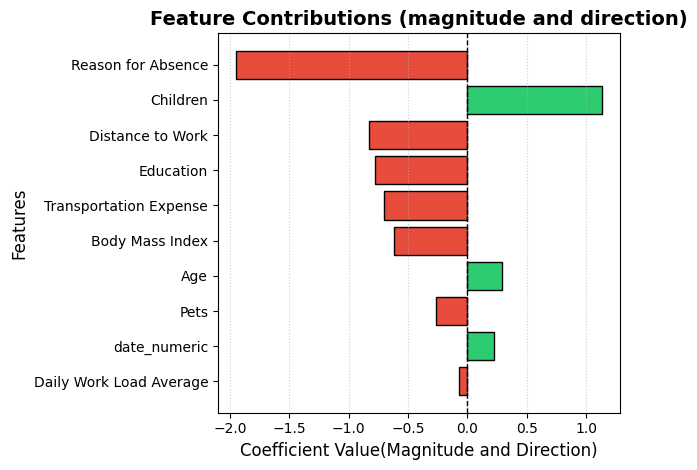

In [41]:
plt.barh(contributions['Feature'], contributions['Coefficient'], color = colors, edgecolor = 'black')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.title('Feature Contributions (magnitude and direction)', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Value(Magnitude and Direction)', fontsize = 12)
plt.ylabel('Features', fontsize= 12)
plt.grid(axis='x' , linestyle=':', alpha=0.6)
plt.tight_layout()


Using Random Forest to solve the same problem

In [42]:
from sklearn.ensemble import RandomForestRegressor

In [43]:
model2 = RandomForestRegressor()
model2.fit(X_trained_scaled, y_train)

RandomForestRegressor()

In [44]:
print(model2.score(X_trained_scaled, y_train))
print(model2.score(X_test_scaled, y_test))

0.8502924812462227
0.07535897648817103


In [45]:
from sklearn.neural_network import MLPRegressor

In [49]:
model3 = MLPRegressor(max_iter=500)

In [50]:
model2.fit(X_trained_scaled, y_train)

RandomForestRegressor()

In [51]:
print(model2.score(X_trained_scaled, y_train))
print(model2.score(X_test_scaled, y_test))

0.8476112486607172
0.1402247412741432
